# Paper3: TabPFN (RF6K + M1) vs Best ML — 12 암종 5-Fold
- **핵심 주장**: RF6K 방식으로 피쳐 500개만 골라 TabPFN 단일 모델(M1)을 쓰는 게, 전체 ~20K 피쳐로 학습한 최고 ML 모델보다 **평균적으로 우수**하다.
- M1 = K=1 (base TabPFN 하나만, stacking 없음)
- 개별 암종에서는 지는 경우도 있지만, 전체 12개 평균에서는 우리가 이긴다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams.update({'figure.dpi': 130, 'font.size': 10})

OLD_BASE = Path('/data2/project/2026winter/jud9679/paper2/final_results')
NEW_BASE = Path('/data2/project/2026winter/jud9679/paper2/move/final_results')
OLD_ML = Path('/data2/project/2026winter/jud9679/paper3/results/ml_old_ref')

ALL_DS = sorted(['BRCA','COADREAD','GEA','KIRCKICH','SKCM','THCA','UCEC','BLCA','HNSC','LGGGBM','LUAD','LUSC'])

In [2]:
# RF6K 5-fold
rf6k_folds = {}
for i in range(1, 6):
    path = NEW_BASE / f'R1F{i}' / 'stacking_v2' / 'metrics_by_k.csv'
    if path.exists():
        df = pd.read_csv(path)
        df['k'] = pd.to_numeric(df['k'], errors='coerce')
        rf6k_folds[f'F{i}'] = df

# ML: 12암종 5fold 평균
ml_data = {}
for f in sorted(OLD_ML.glob('Exp1_2_*.csv')):
    df = pd.read_csv(f)
    ds = f.stem.replace('Exp1_2_', '')
    ml_data[ds] = {}
    for model, grp in df.groupby('Model'):
        ml_data[ds][model] = grp['F1_Weighted'].mean()

def get_rf6k(ds, k):
    vals = []
    for fold_df in rf6k_folds.values():
        sub = fold_df[(fold_df['dataset']==ds) & (fold_df['k']==k)]
        if len(sub) > 0: vals.append(float(sub.iloc[0]['f1_weighted']))
    return (np.mean(vals), np.std(vals)) if vals else (np.nan, np.nan)

def get_ml_best(ds):
    if ds not in ml_data or not ml_data[ds]: return np.nan, 'N/A'
    best = max(ml_data[ds], key=ml_data[ds].get)
    return ml_data[ds][best], best

print(f'RF6K: {len(rf6k_folds)} folds | ML: {len(ml_data)} datasets (all 5-fold)')

RF6K: 5 folds | ML: 12 datasets (all 5-fold)


## 1. 12암종 개별 비교 (M1 vs Best ML)
- 각 막대: 해당 암종의 5-fold 평균 F1
- 라벨: TabPFN(M1) - Best ML 차이


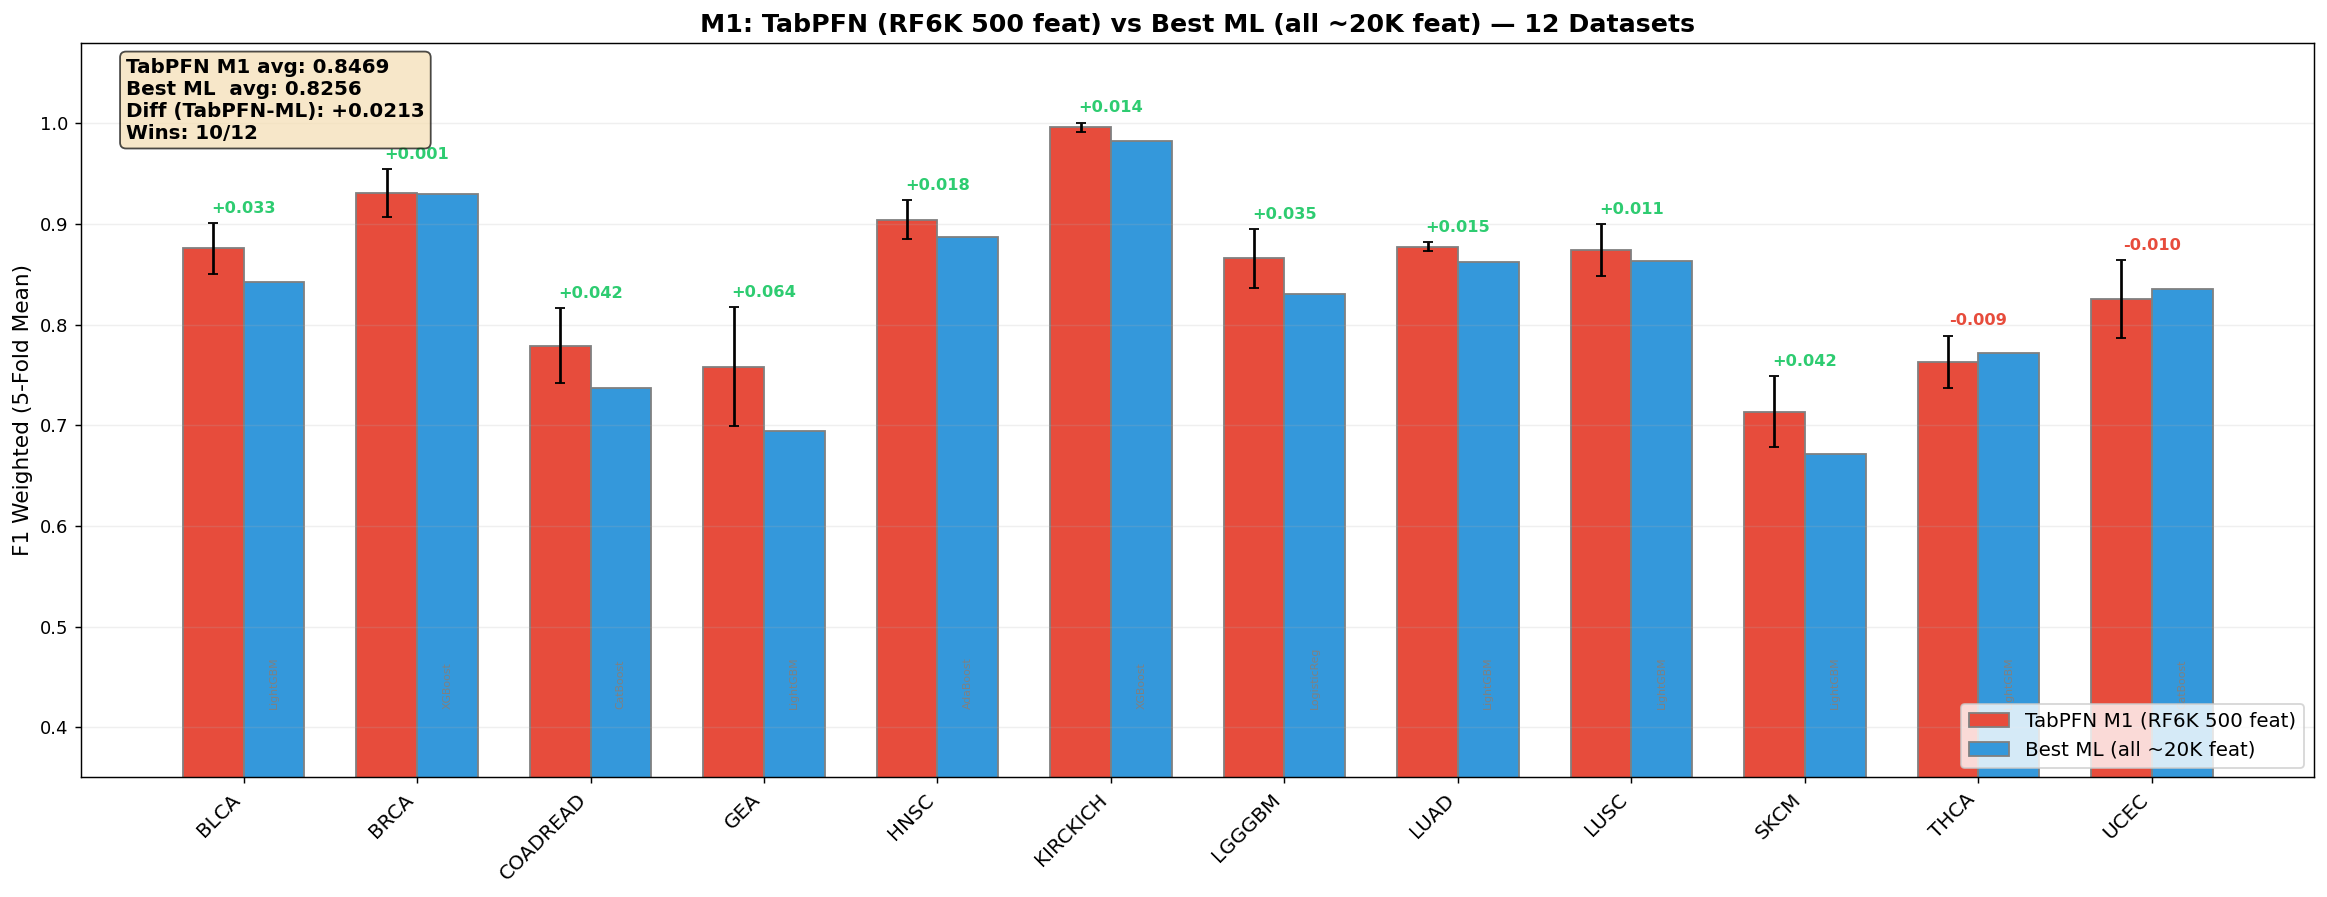

In [3]:
K = 1  # M1 only
fig, ax = plt.subplots(figsize=(18, 7))
x = np.arange(len(ALL_DS))
width = 0.35

t_vals, t_errs = zip(*[get_rf6k(ds, K) for ds in ALL_DS])
t_vals = [v if not np.isnan(v) else 0 for v in t_vals]
t_errs = [v if not np.isnan(v) else 0 for v in t_errs]
m_vals = [get_ml_best(ds)[0] if not np.isnan(get_ml_best(ds)[0]) else 0 for ds in ALL_DS]
m_names = [get_ml_best(ds)[1] for ds in ALL_DS]

bars_t = ax.bar(x - width/2, t_vals, width, yerr=t_errs, capsize=3,
       label='TabPFN M1 (RF6K 500 feat)', color='#e74c3c', edgecolor='gray')
bars_m = ax.bar(x + width/2, m_vals, width,
       label='Best ML (all ~20K feat)', color='#3498db', edgecolor='gray')

for i in range(len(ALL_DS)):
    diff = t_vals[i] - m_vals[i]
    y = max(t_vals[i] + t_errs[i], m_vals[i]) + 0.01
    color = '#2ecc71' if diff > 0 else '#e74c3c'
    ax.text(i, y, f'{diff:+.3f}', ha='center', fontsize=9, fontweight='bold', color=color)
    ax.text(i + width/2, 0.42, m_names[i], ha='center', fontsize=6, rotation=90, color='gray')

ax.set_xticks(x)
ax.set_xticklabels(ALL_DS, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('F1 Weighted (5-Fold Mean)', fontsize=12)
ax.set_title('M1: TabPFN (RF6K 500 feat) vs Best ML (all ~20K feat) — 12 Datasets',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0.35, 1.08)
ax.grid(True, alpha=0.2, axis='y')

wins = sum(1 for i in range(len(ALL_DS)) if t_vals[i] > m_vals[i])
avg_t = np.mean(t_vals)
avg_m = np.mean(m_vals)
ax.text(0.02, 0.98,
        f'TabPFN M1 avg: {avg_t:.4f}\nBest ML  avg: {avg_m:.4f}\nDiff (TabPFN-ML): {avg_t-avg_m:+.4f}\nWins: {wins}/12',
        transform=ax.transAxes, fontsize=11, va='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('paper3_M1_vs_bestML.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. 전체 평균 비교 (핵심 주장)
- 암종별 승/패와 상관 없이, **12개 평균**에서 우리가 이긴다는 게 핵심


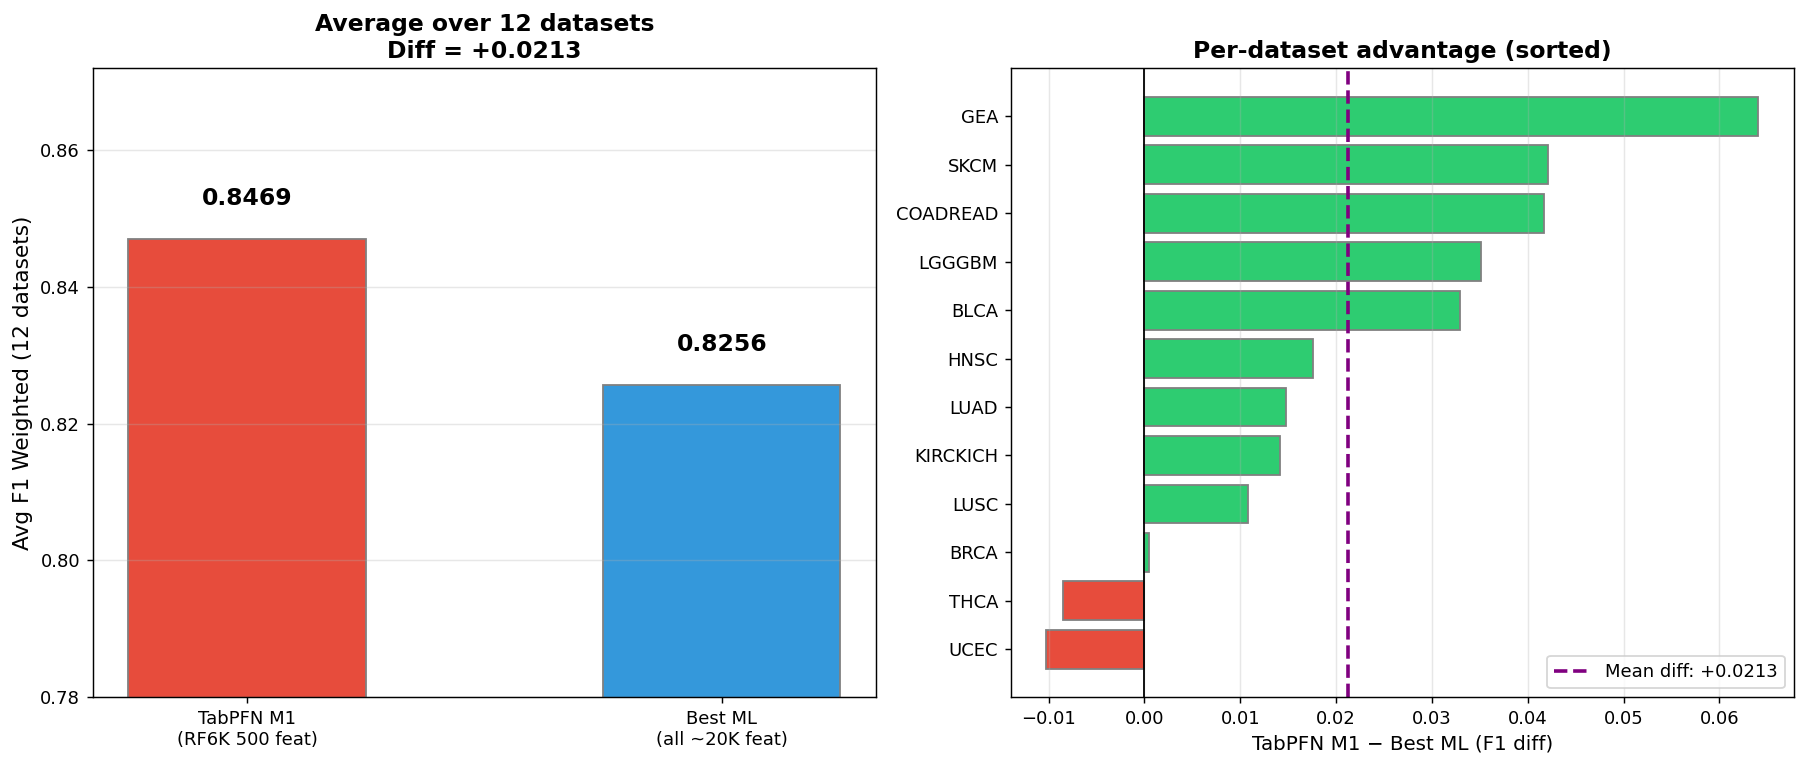

=== Paper3 핵심 결과 ===
  TabPFN M1 (RF6K 500 feat) 평균: 0.8469
  Best ML (all ~20K feat)  평균: 0.8256
  평균 차이:                    +0.0213
  개별 승률:                    10/12

지는 암종:
  UCEC: -0.0102
  THCA: -0.0085

이기는 암종:
  BRCA: +0.0005
  LUSC: +0.0108
  KIRCKICH: +0.0141
  LUAD: +0.0148
  HNSC: +0.0176
  BLCA: +0.0330
  LGGGBM: +0.0351
  COADREAD: +0.0418
  SKCM: +0.0421
  GEA: +0.0641


In [4]:
# 전체 평균 비교 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 좌: 평균 비교
ax = axes[0]
avg_tabpfn = np.mean(t_vals)
avg_ml = np.mean(m_vals)
bars = ax.bar(['TabPFN M1\n(RF6K 500 feat)', 'Best ML\n(all ~20K feat)'],
               [avg_tabpfn, avg_ml],
               color=['#e74c3c', '#3498db'], edgecolor='gray', width=0.5)
for b, v in zip(bars, [avg_tabpfn, avg_ml]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.4f}',
            ha='center', fontsize=13, fontweight='bold')

diff = avg_tabpfn - avg_ml
ax.set_ylabel('Avg F1 Weighted (12 datasets)', fontsize=12)
ax.set_title(f'Average over 12 datasets\nDiff = {diff:+.4f}',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.78, max(avg_tabpfn, avg_ml) + 0.025)
ax.grid(True, alpha=0.3, axis='y')

# 우: 암종별 diff (정렬)
ax = axes[1]
diffs = [(ds, t_vals[i] - m_vals[i]) for i, ds in enumerate(ALL_DS)]
diffs.sort(key=lambda x: x[1])
ds_sorted = [d[0] for d in diffs]
diff_vals = [d[1] for d in diffs]
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in diff_vals]
ax.barh(ds_sorted, diff_vals, color=colors, edgecolor='gray')
ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=np.mean(diff_vals), color='purple', linestyle='--', linewidth=2,
           label=f'Mean diff: {np.mean(diff_vals):+.4f}')
ax.set_xlabel('TabPFN M1 − Best ML (F1 diff)', fontsize=11)
ax.set_title('Per-dataset advantage (sorted)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('paper3_M1_avg_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 텍스트 요약
print(f'=== Paper3 핵심 결과 ===')
print(f'  TabPFN M1 (RF6K 500 feat) 평균: {avg_tabpfn:.4f}')
print(f'  Best ML (all ~20K feat)  평균: {avg_ml:.4f}')
print(f'  평균 차이:                    {avg_tabpfn - avg_ml:+.4f}')
print(f'  개별 승률:                    {wins}/12')
print()
print('지는 암종:')
for ds, d in diffs:
    if d <= 0:
        print(f'  {ds}: {d:+.4f}')
print()
print('이기는 암종:')
for ds, d in diffs:
    if d > 0:
        print(f'  {ds}: {d:+.4f}')


## 3. 수치 테이블


In [5]:
rows = []
for ds in ALL_DS:
    t, s = get_rf6k(ds, 1)
    m, mn = get_ml_best(ds)
    rows.append({
        'Dataset': ds,
        'TabPFN M1': round(t, 4) if not np.isnan(t) else None,
        'Best ML': round(m, 4) if not np.isnan(m) else None,
        'ML Model': mn,
        'Diff': round(t - m, 4) if not (np.isnan(t) or np.isnan(m)) else None,
        'Win': 'O' if (not np.isnan(t) and not np.isnan(m) and t > m) else 'X',
    })
df_m1 = pd.DataFrame(rows)

# 평균 row 추가
avg_row = {
    'Dataset': 'Average',
    'TabPFN M1': round(df_m1['TabPFN M1'].mean(), 4),
    'Best ML': round(df_m1['Best ML'].mean(), 4),
    'ML Model': '-',
    'Diff': round(df_m1['TabPFN M1'].mean() - df_m1['Best ML'].mean(), 4),
    'Win': f"{sum(df_m1['Win']=='O')}/12",
}
df_full = pd.concat([df_m1, pd.DataFrame([avg_row])], ignore_index=True)
display(df_full)


,Dataset,TabPFN M1,Best ML,ML Model,Diff,Win
0,BLCA,0.8756,0.8427,LightGBM,0.0330,O
1,BRCA,0.9308,0.9303,XGBoost,0.0005,O
2,COADREAD,0.7790,0.7373,CatBoost,0.0418,O
3,GEA,0.7580,0.6940,LightGBM,0.0641,O
4,HNSC,0.9044,0.8868,AdaBoost,0.0176,O
5,KIRCKICH,0.9963,0.9822,XGBoost,0.0141,O
6,LGGGBM,0.8660,0.8308,LogisticReg,0.0351,O
7,LUAD,0.8775,0.8627,LightGBM,0.0148,O
8,LUSC,0.8738,0.8629,LightGBM,0.0108,O
9,SKCM,0.7134,0.6712,LightGBM,0.0421,O
